# Capítulo 6 · Descenso por gradiente

En el capítulo anterior aprendimos a medir el error y observamos que la pérdida cambia cuando modificamos un parámetro. Ahora daremos el paso siguiente: **utilizar la pendiente de esa función para decidir cómo corregir el parámetro**.

Trabajaremos primero con un único peso y una función deliberadamente sencilla. Después extenderemos la misma intuición a dos parámetros. El propósito es ver cada actualización antes de utilizar un framework que realice estas operaciones automáticamente.

## Objetivos del cuaderno

Al finalizar este recorrido podrás:

- interpretar el signo y la magnitud de una pendiente;
- aplicar manualmente la regla del descenso por gradiente;
- observar cómo cambian un parámetro y la pérdida durante varias actualizaciones;
- comparar el efecto de distintos valores de *learning rate*;
- reconocer descensos lentos, oscilaciones y divergencia;
- interpretar una superficie de pérdida con dos parámetros;
- distinguir descenso por gradiente de backpropagation.

## Importación de librerías

Usaremos NumPy para los cálculos, Pandas para organizar las actualizaciones y Matplotlib para visualizar las trayectorias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.6f}".format

## 1. Recuperar el paisaje de pérdida

Continuaremos con la función presentada en el capítulo:

$$L(w)=(w-3)^2$$

Su mínimo se encuentra en $w=3$. En un problema real no conoceríamos de antemano el valor óptimo, pero aquí esa referencia nos permitirá comprobar si las actualizaciones avanzan en una dirección conveniente.

La derivada de la función es:

$$\frac{dL}{dw}=2(w-3)$$

No desarrollaremos técnicas de cálculo diferencial. Nos interesa interpretar este resultado como una medida de la pendiente local.

In [2]:
def perdida(w):
    return (w - 3) ** 2

def gradiente(w):
    return 2 * (w - 3)

valores_w = np.array([-1, 0, 2, 3, 4, 5], dtype=float)
gradientes = gradiente(valores_w)

direcciones = np.where(
    gradientes < 0,
    "Aumentar w",
    np.where(gradientes > 0, "Disminuir w", "Sin cambio en este ejemplo"),
)

tabla_pendientes = pd.DataFrame({
    "w": valores_w,
    "L(w)": perdida(valores_w),
    "Gradiente": gradientes,
    "Dirección para descender": direcciones,
})

display(tabla_pendientes)

,w,L(w),Gradiente,Dirección para descender
0,-1.000000,16.000000,-8.000000,Aumentar w
1,0.000000,9.000000,-6.000000,Aumentar w
2,2.000000,1.000000,-2.000000,Aumentar w
3,3.000000,0.000000,0.000000,Sin cambio en este ejemplo
4,4.000000,1.000000,2.000000,Disminuir w
5,5.000000,4.000000,4.000000,Disminuir w


A la izquierda del mínimo, el gradiente es negativo: para reducir la pérdida debemos aumentar `w`. A la derecha, el gradiente es positivo y debemos disminuirlo. En `w = 3`, el gradiente vale cero y la curva es horizontal.

La dirección de descenso es siempre la contraria al signo del gradiente.

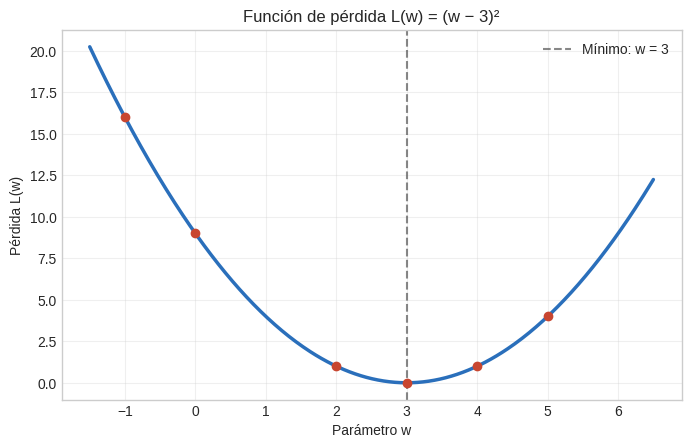

In [3]:
w_curva = np.linspace(-1.5, 6.5, 400)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(w_curva, perdida(w_curva), color="#2a6fbb", linewidth=2.5)
ax.scatter(valores_w, perdida(valores_w), color="#c84630", zorder=3)
ax.axvline(3, color="#555555", linestyle="--", alpha=0.7, label="Mínimo: w = 3")
ax.set_title("Función de pérdida L(w) = (w − 3)²")
ax.set_xlabel("Parámetro w")
ax.set_ylabel("Pérdida L(w)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

La altura de la curva representa la pérdida. Descender no significa moverse siempre hacia la derecha o siempre hacia la izquierda: la dirección depende de la posición actual.

### Comprobar la pendiente con un cambio pequeño

La derivada expresa qué ocurre con la pérdida ante una modificación muy pequeña de `w`. Podemos aproximar esa idea comparando dos puntos cercanos.

In [4]:
w_actual = 0.0
cambio_pequeno = 0.001

pendiente_aproximada = (
    perdida(w_actual + cambio_pequeno) - perdida(w_actual)
) / cambio_pequeno

print(f"Gradiente calculado con la fórmula: {gradiente(w_actual):.6f}")
print(f"Pendiente aproximada numéricamente: {pendiente_aproximada:.6f}")

Gradiente calculado con la fórmula: -6.000000
Pendiente aproximada numéricamente: -5.999000


En `w = 0`, la fórmula produce un gradiente de `−6`. La aproximación numérica queda muy cerca de ese valor. El signo negativo indica que un pequeño aumento de `w` reduce la pérdida.

## 2. Una actualización completa

La regla básica del descenso por gradiente es:

$$w_{\text{nuevo}}=w_{\text{actual}}-\eta\frac{dL}{dw}$$

$\eta$ es el *learning rate* o tasa de aprendizaje. Controla la escala de la actualización. Empezaremos en $w=0$ y utilizaremos $\eta=0.1$.

In [5]:
w_actual = 0.0
learning_rate = 0.1

gradiente_actual = gradiente(w_actual)
cambio = -learning_rate * gradiente_actual
w_nuevo = w_actual + cambio

primer_paso = pd.DataFrame({
    "Situación": ["Antes", "Después"],
    "w": [w_actual, w_nuevo],
    "L(w)": [perdida(w_actual), perdida(w_nuevo)],
})

display(primer_paso)
print(f"Gradiente utilizado: {gradiente_actual:.2f}")
print(f"Cambio aplicado a w: {cambio:.2f}")

,Situación,w,L(w)
0,Antes,0.000000,9.000000
1,Después,0.600000,5.760000


Gradiente utilizado: -6.00
Cambio aplicado a w: 0.60


El gradiente era `−6`. Al multiplicarlo por `−0.1`, el cambio resulta positivo: `w` pasa de `0` a `0.6`. La pérdida disminuye de `9` a `5.76`.

La derivada no indicó que la solución era `w = 3`; solamente aportó información sobre la posición actual. Después de movernos será necesario calcular nuevamente el gradiente.

## 3. Repetir las actualizaciones

El siguiente código reúne el procedimiento en una función sencilla. En cada paso registra la posición actual, la pérdida, el gradiente y el cambio que se aplicará.

La función no representa todavía una red neuronal. Implementa directamente el descenso sobre nuestra parábola para que cada operación permanezca visible.

In [6]:
def ejecutar_descenso(w_inicial, learning_rate, cantidad_pasos):
    w = float(w_inicial)
    historial = []

    for paso in range(cantidad_pasos + 1):
        grad = gradiente(w)
        cambio = -learning_rate * grad if paso < cantidad_pasos else np.nan

        historial.append({
            "Paso": paso,
            "w": w,
            "L(w)": perdida(w),
            "Gradiente": grad,
            "Cambio siguiente": cambio,
        })

        if paso < cantidad_pasos:
            w = w + cambio

    return pd.DataFrame(historial)

recorrido = ejecutar_descenso(
    w_inicial=0.0,
    learning_rate=0.1,
    cantidad_pasos=12,
)

display(recorrido)

,Paso,w,L(w),Gradiente,Cambio siguiente
0,0,0.000000,9.000000,-6.000000,0.600000
1,1,0.600000,5.760000,-4.800000,0.480000
2,2,1.080000,3.686400,-3.840000,0.384000
3,3,1.464000,2.359296,-3.072000,0.307200
4,4,1.771200,1.509949,-2.457600,0.245760
5,5,2.016960,0.966368,-1.966080,0.196608
6,6,2.213568,0.618475,-1.572864,0.157286
7,7,2.370854,0.395824,-1.258291,0.125829
8,8,2.496684,0.253327,-1.006633,0.100663
9,9,2.597347,0.162130,-0.805306,0.080531


Las primeras posiciones son `0.6`, `1.08` y `1.464`, como en el desarrollo manual del capítulo. La pérdida disminuye en cada paso y el valor absoluto del gradiente también se reduce.

Aunque el *learning rate* permanece en `0.1`, las actualizaciones se hacen más pequeñas porque la curva se vuelve más plana cerca del mínimo.

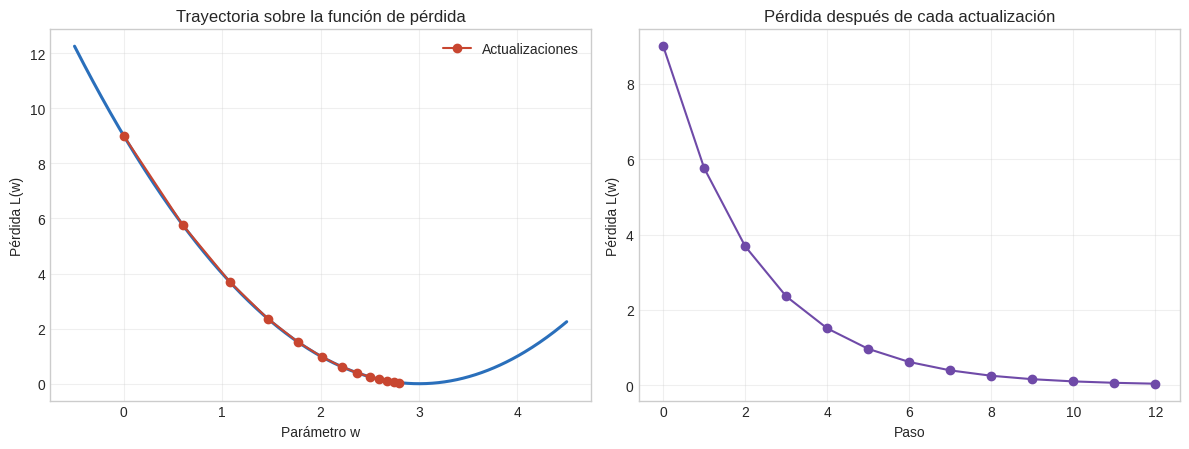

In [7]:
w_curva = np.linspace(-0.5, 4.5, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

axes[0].plot(w_curva, perdida(w_curva), color="#2a6fbb", linewidth=2.2)
axes[0].plot(
    recorrido["w"],
    recorrido["L(w)"],
    "o-",
    color="#c84630",
    label="Actualizaciones",
)
axes[0].set_title("Trayectoria sobre la función de pérdida")
axes[0].set_xlabel("Parámetro w")
axes[0].set_ylabel("Pérdida L(w)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    recorrido["Paso"],
    recorrido["L(w)"],
    "o-",
    color="#6f4aa8",
)
axes[1].set_title("Pérdida después de cada actualización")
axes[1].set_xlabel("Paso")
axes[1].set_ylabel("Pérdida L(w)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

El gráfico izquierdo muestra el recorrido sobre la parábola. El derecho deja ver que la reducción es rápida al principio y luego se vuelve más gradual.

Este comportamiento es un ejemplo de **convergencia**: las sucesivas actualizaciones se acercan a una región estable y producen mejoras cada vez menores. Convergencia no significa necesariamente que una red real haya encontrado una solución perfecta ni que generalice bien; describe el comportamiento de la optimización.

## 4. El efecto del *learning rate*

La dirección aportada por el gradiente no basta: también importa cuánto avanzamos. Compararemos cinco tasas de aprendizaje desde el mismo punto inicial y durante la misma cantidad de pasos.

| *Learning rate* | Comportamiento esperado en esta función |
|---:|---|
| `0.01` | Descenso estable, pero lento |
| `0.10` | Acercamiento progresivo |
| `0.20` | Acercamiento más rápido |
| `1.00` | Oscilación entre ambos lados |
| `1.10` | Alejamiento progresivo o divergencia |

Estas observaciones corresponden a esta función concreta. No existe un valor universal que se comporte igual en todos los problemas.

In [8]:
tasas = [0.01, 0.10, 0.20, 1.00, 1.10]
recorridos = {}
resumen = []

for tasa in tasas:
    historial = ejecutar_descenso(
        w_inicial=0.0,
        learning_rate=tasa,
        cantidad_pasos=12,
    )
    recorridos[tasa] = historial
    resumen.append({
        "Learning rate": tasa,
        "w final": historial.iloc[-1]["w"],
        "Pérdida inicial": historial.iloc[0]["L(w)"],
        "Pérdida final": historial.iloc[-1]["L(w)"],
    })

resumen_tasas = pd.DataFrame(resumen)
display(resumen_tasas)

,Learning rate,w final,Pérdida inicial,Pérdida final
0,0.010000,0.645850,9.000000,5.542023
1,0.100000,2.793842,9.000000,0.042501
2,0.200000,2.993470,9.000000,0.000043
3,1.000000,0.000000,9.000000,9.000000
4,1.100000,-23.748301,9.000000,715.471625


Con `0.01` la pérdida disminuye, pero después de doce pasos todavía supera `5`. Las tasas `0.10` y `0.20` se acercan al mínimo con distinta rapidez. Con `1.00`, el parámetro alterna entre `0` y `6`, de modo que la pérdida permanece en `9`. Con `1.10`, los saltos crecen y la pérdida aumenta: el proceso diverge.

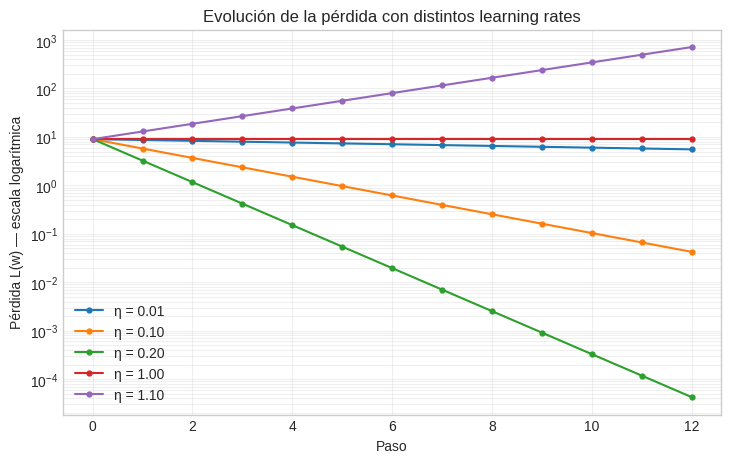

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5))

for tasa, historial in recorridos.items():
    ax.plot(
        historial["Paso"],
        historial["L(w)"],
        marker="o",
        markersize=3.5,
        label=f"η = {tasa:.2f}",
    )

ax.set_yscale("log")
ax.set_title("Evolución de la pérdida con distintos learning rates")
ax.set_xlabel("Paso")
ax.set_ylabel("Pérdida L(w) — escala logarítmica")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

La escala logarítmica permite mostrar en un mismo gráfico pérdidas muy pequeñas y otras que crecen con rapidez. La línea horizontal de `η = 1.00` representa la oscilación: el parámetro cambia de lado, pero la distancia al mínimo se conserva.

Un *learning rate* grande no es necesariamente mejor por avanzar más en el primer paso. La estabilidad depende de la relación entre la tasa y la forma de la función.

## 5. De una curva a una superficie

Con dos parámetros podemos representar una superficie de pérdida. Usaremos:

$$L(w_1,w_2)=(w_1-2)^2+(w_2+1)^2$$

El mínimo se encuentra en $(2,-1)$. El gradiente reúne una derivada para cada parámetro:

$$\nabla L=\left[2(w_1-2),\;2(w_2+1)\right]$$

Como conocemos directamente este gradiente sencillo, podemos actualizar ambos parámetros a la vez. Todavía no estamos calculando gradientes a través de capas de una red; ese problema corresponde a backpropagation.

In [10]:
def perdida_dos_parametros(w1, w2):
    return (w1 - 2) ** 2 + (w2 + 1) ** 2

def gradiente_dos_parametros(w1, w2):
    return np.array([2 * (w1 - 2), 2 * (w2 + 1)])

parametros = np.array([-3.0, 4.0])
learning_rate_2d = 0.1
trayectoria_2d = []

for paso in range(19):
    trayectoria_2d.append({
        "Paso": paso,
        "w1": parametros[0],
        "w2": parametros[1],
        "Pérdida": perdida_dos_parametros(*parametros),
    })
    parametros = parametros - learning_rate_2d * gradiente_dos_parametros(*parametros)

trayectoria_2d = pd.DataFrame(trayectoria_2d)

display(trayectoria_2d.head(6))
display(trayectoria_2d.tail(3))

,Paso,w1,w2,Pérdida
0,0,-3.000000,4.000000,50.000000
1,1,-2.000000,3.000000,32.000000
2,2,-1.200000,2.200000,20.480000
3,3,-0.560000,1.560000,13.107200
4,4,-0.048000,1.048000,8.388608
5,5,0.361600,0.638400,5.368709


,Paso,w1,w2,Pérdida
16,16,1.859263,-0.859263,0.039614
17,17,1.887410,-0.887410,0.025353
18,18,1.909928,-0.909928,0.016226


Cada fila representa una combinación de `w1` y `w2`. Ambos parámetros reciben correcciones distintas, calculadas a partir de sus propias componentes del gradiente. La pérdida desciende desde `50` hasta un valor cercano a `0.017`.

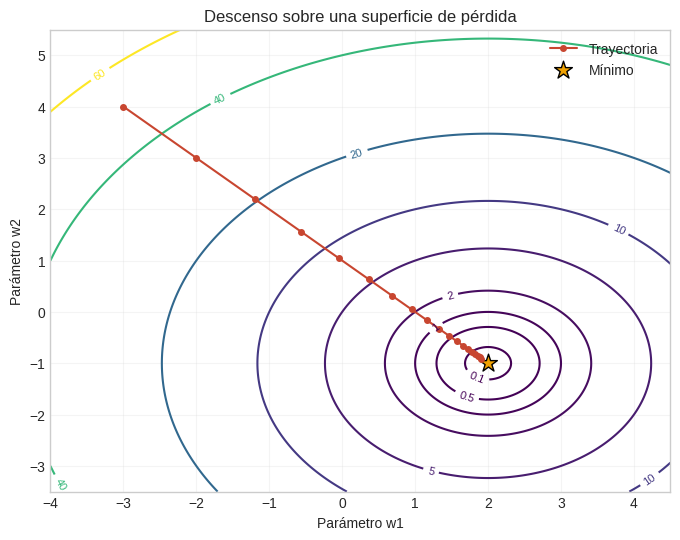

In [11]:
w1_grid = np.linspace(-4, 4.5, 260)
w2_grid = np.linspace(-3.5, 5.5, 260)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = perdida_dos_parametros(W1, W2)

fig, ax = plt.subplots(figsize=(8, 6))
niveles = [0.1, 0.5, 1, 2, 5, 10, 20, 40, 60]
contornos = ax.contour(W1, W2, Z, levels=niveles, cmap="viridis")
ax.clabel(contornos, inline=True, fontsize=8, fmt="%g")
ax.plot(
    trayectoria_2d["w1"],
    trayectoria_2d["w2"],
    "o-",
    color="#c84630",
    markersize=4,
    label="Trayectoria",
)
ax.scatter(2, -1, marker="*", s=180, color="#f0a202", edgecolor="black", label="Mínimo")
ax.set_title("Descenso sobre una superficie de pérdida")
ax.set_xlabel("Parámetro w1")
ax.set_ylabel("Parámetro w2")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

Las líneas de contorno unen combinaciones con la misma pérdida. La trayectoria roja cruza líneas con valores cada vez menores y se dirige hacia el mínimo.

Una red real contiene muchos más parámetros y ya no puede representarse en un plano. La interpretación, sin embargo, permanece: el gradiente reúne información local y permite actualizar cada componente en dirección contraria al crecimiento de la pérdida.

## 6. Actividad breve

Modificá el punto inicial, el *learning rate* y la cantidad de pasos. Probá comenzar a ambos lados del mínimo y observá cómo cambia el signo del gradiente.

Si elegís una tasa grande, prestá atención a la pérdida: moverse en la dirección local correcta no garantiza que el paso tenga un tamaño adecuado.

In [12]:
# Modificá estos tres valores y volvé a ejecutar la celda.
w_inicial_actividad = 5.0
learning_rate_actividad = 0.15
pasos_actividad = 10

actividad = ejecutar_descenso(
    w_inicial=w_inicial_actividad,
    learning_rate=learning_rate_actividad,
    cantidad_pasos=pasos_actividad,
)

display(actividad)

print(f"Pérdida inicial: {actividad.iloc[0]['L(w)']:.6f}")
print(f"Pérdida final:   {actividad.iloc[-1]['L(w)']:.6f}")

,Paso,w,L(w),Gradiente,Cambio siguiente
0,0,5.000000,4.000000,4.000000,-0.600000
1,1,4.400000,1.960000,2.800000,-0.420000
2,2,3.980000,0.960400,1.960000,-0.294000
3,3,3.686000,0.470596,1.372000,-0.205800
4,4,3.480200,0.230592,0.960400,-0.144060
5,5,3.336140,0.112990,0.672280,-0.100842
6,6,3.235298,0.055365,0.470596,-0.070589
7,7,3.164709,0.027129,0.329417,-0.049413
8,8,3.115296,0.013293,0.230592,-0.034589
9,9,3.080707,0.006514,0.161414,-0.024212


Pérdida inicial: 4.000000
Pérdida final:   0.003192


Con los valores iniciales de la actividad, el parámetro comienza a la derecha del mínimo. El gradiente es positivo, por lo que las actualizaciones disminuyen `w`. Después de diez pasos, la pérdida queda muy cerca de cero.

No hace falta buscar el valor que produzca exactamente `0`. El objetivo es reconocer la relación entre posición, gradiente, tamaño de paso y evolución de la pérdida.

## Qué hicimos y qué falta

En este cuaderno partimos de gradientes que ya conocíamos porque las funciones eran muy sencillas. Una vez disponible el gradiente, aplicamos la regla de actualización y observamos cómo los parámetros se desplazaban hacia regiones de menor pérdida.

En una red profunda, la pérdida se calcula al final de muchas capas y operaciones. Todavía no explicamos cómo determinar la influencia de cada peso sobre ese resultado final. **Backpropagation** resolverá ese problema en el capítulo siguiente.

Tampoco trabajamos con épocas, batches ni optimizadores como SGD o Adam. Esos elementos se introducirán después de comprender cómo se propaga el error a través de la red.

## Cierre

El descenso por gradiente transforma la información de la pendiente en una sucesión de correcciones. El signo del gradiente orienta el movimiento, mientras que su magnitud y el *learning rate* determinan cuánto cambia cada parámetro.

Comprobamos que una tasa muy pequeña puede volver lento el descenso, una tasa razonable puede producir convergencia y una tasa excesiva puede causar oscilaciones o divergencia. También extendimos la intuición desde una curva con un parámetro hasta una superficie con dos.

Ya sabemos qué hacer cuando disponemos de los gradientes. El próximo capítulo responderá la pregunta pendiente: cómo obtenerlos eficientemente en una red con varias capas.

## Para pensar

1. ¿Por qué el descenso por gradiente se mueve en sentido contrario al signo de la pendiente?
2. ¿Cómo puede un *learning rate* grande impedir el aprendizaje aunque el gradiente indique la dirección correcta?
3. ¿Qué parte del proceso todavía falta explicar cuando una red contiene muchas capas y parámetros?